# **Анализ ежемесячного пассажиропотока в московском транспорте в период в 2019 по 2025 года.**

## **Описание**

Наш проект представляет собой анализ ежемесячного пассажиропотока в Московском транспорте в 2019 – 2025 годах в разных видах общественного транспорта (автобус, троллейбус, электробус, трамвай, метрополитен и МЦК). Анализ в работе проведен в двух видах: суммарный (все виды транспорта) ежемесячный пассажиропоток за определенные года: 2019 (до пандемии), 2020 (во время пандемии) и 2024 (после пандемии, нынешние времена), и анализ ежемесячного пассажиропотока на каждый вид общественного транспорта Москвы. Он включает в себя несколько функций, которые обрабатывают и анализируют данные по ежемесячным пассажиропотокам на различных видах транспорта, создавая графики с этими данными. Наш проект позволяет: 
- Извлекать данные из CSV-файла и превращать их в списки для анализа
- Cуммировать данные о количествах пассажиров за каждый месяц на всех видах транспорта
- Возвращать графики с ежемесячным пассажиропотоком за все виды транпорта или по отдельности
- Сделает анализ, рассматривая графики потоков за каждый месяц в разные года, находя связь с различными событиями. 

1. Импорт необходимых библиотек и открытие CSV-файла с данными

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

with open('C:/Users/nik99/OneDrive/конспкеты/data-62521-2025-10-06.csv', encoding='utf8') as transdata:
    passpotoki = transdata.read().split('\n')

### **2. Анализ ежемесячного суммарного пассажиропотока за 2019, 2020 и 2024 года**
   
   2.1 Добавление списка пассажиропотока (passengers), создание переменной суммы (summ) и переменная предыдущего месяца (previous_month) и вводим цикл,        в котором с помощью условий проводим обработку данных

In [15]:
passengers = []
summ = 0
previous_month = None

#вводим цикл, где считываем данные построчно, исключая первые две строки с названиями столбцоы и последней пустой строкой
for i in passpotoki[2:-1]:
    stroka = i[:-1].split(';')
    current_month = stroka[2].split('"')[1]
        
    #проверяем, равен ли год из строки году, по которому мы хотим построить график, если нет, то пропускаем текущую итерацию цикла
    if stroka[1].split('"')[1] != '2019':
        continue
            
    #для внесения в элемент списка данные только одного месяца (суммирование), из списка, данные с определенным месяцем находятся в одном месте, необходима проверка, равен ли месяц данной строки предыдущей, если нет, то данные с этих строк отличаются, и их нельзя суммировать
    if current_month == previous_month:
        summ += int(stroka[4].split('"')[1])

    #При несовпадении месяцев, и когда он не нулевой (None) добавляем сумму в список, а сам список равняется первому количеству пассажиров в новом месяце    
    else:
        if previous_month is not None:
            passengers.append(summ / (10**6))
        summ = int(stroka[4].split('"')[1])
        previous_month = current_month
            
#добавление последнего месяца
if previous_month is not None:
    passengers.append(summ / (10**6))
        
#вывод списка из значений пассажиропотка за 12 месяцев
print(passengers)


[316.508982, 336.990672, 370.303004, 379.021153, 333.930871, 319.781453, 323.769764, 318.117427, 351.47479, 391.118644, 364.569729, 387.400365]


2.2. Создание графиков и последующий анализ

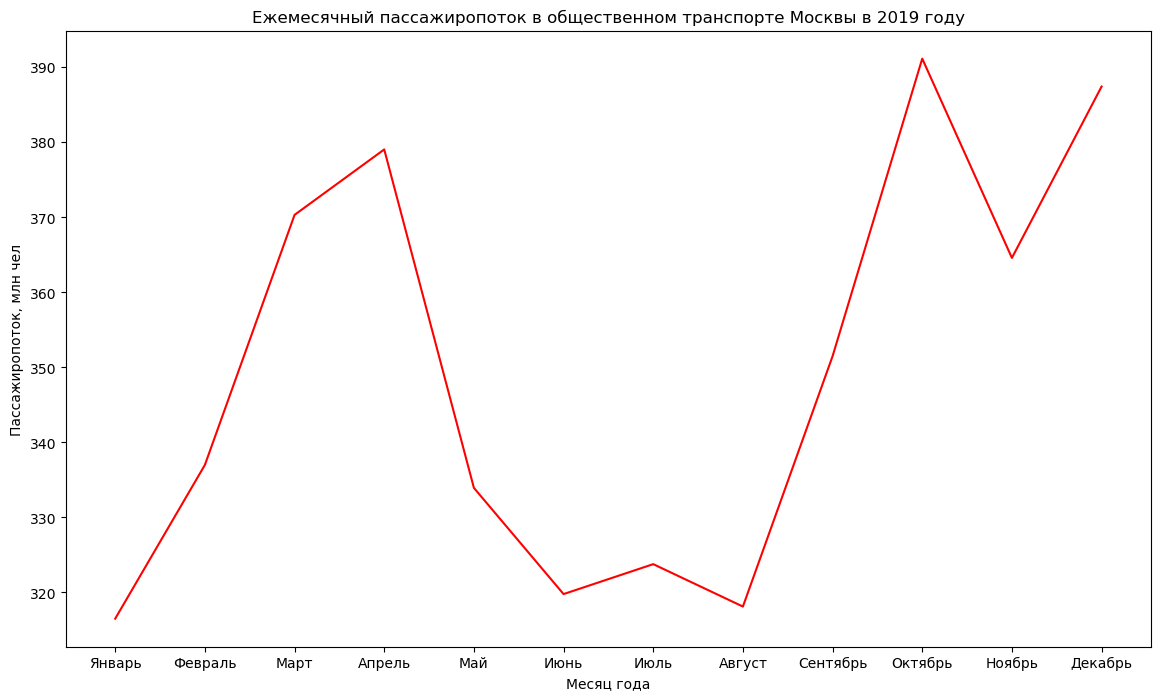

In [16]:
#создание нового списка с месяцами для таблицы (оси x)
months = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
plt.figure(figsize=(14,8))
plt.plot(months, passengers, color='red')
plt.xlabel('Месяц года')
plt.ylabel('Пассажиропоток, млн чел')
plt.title('Ежемесячный пассажиропоток в общественном транспорте Москвы в 2019 году')
plt.show()

2.3 Создание еще двух аналогичных графиков с такими же кодами, но изменными годами

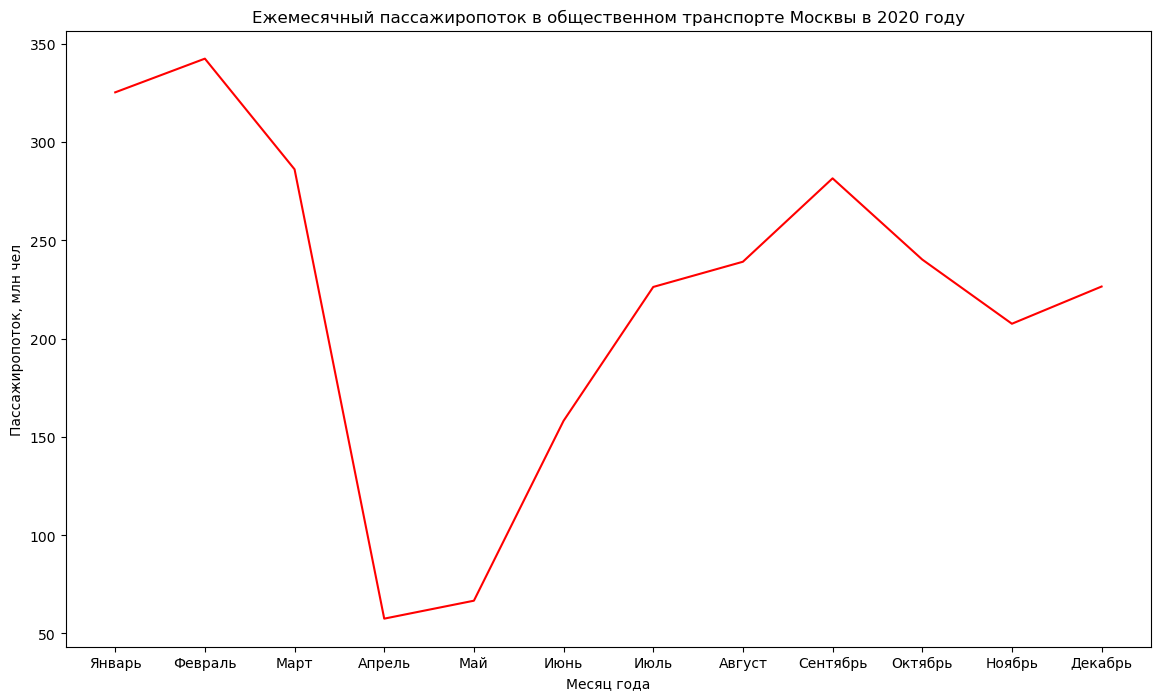

In [24]:
passengers = []
summ = 0
previous_month = None
for i in passpotoki[2:-1]:
    stroka = i[:-1].split(';')
    current_month = stroka[2].split('"')[1]

    if stroka[1].split('"')[1] != '2020':
            continue

    if current_month == previous_month:
            summ += int(stroka[4].split('"')[1])
    else:
        if previous_month is not None:
            passengers.append(summ / (10**6))
        summ = int(stroka[4].split('"')[1])
        previous_month = current_month

if previous_month is not None:
    passengers.append(summ / (10**6))

months = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
plt.figure(figsize=(14,8))
plt.plot(months, passengers, color='red')
plt.xlabel('Месяц года')
plt.ylabel('Пассажиропоток, млн чел')
plt.title('Ежемесячный пассажиропоток в общественном транспорте Москвы в 2020 году')
plt.show()

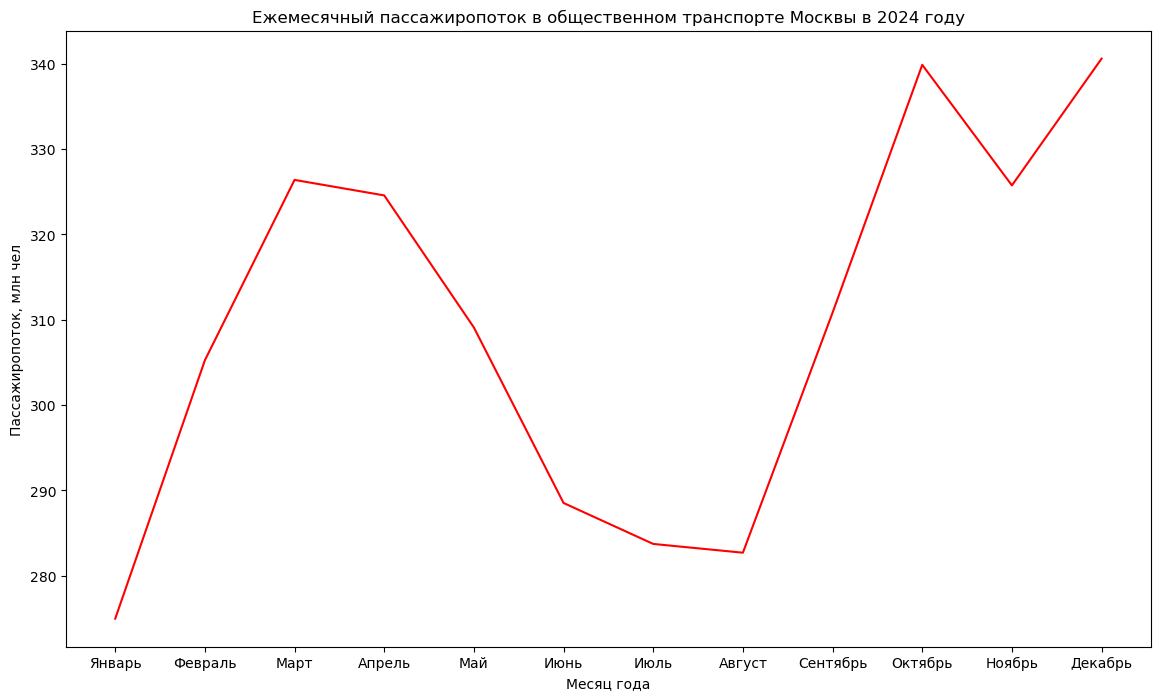

In [11]:
passengers = []
summ = 0
previous_month = None
for i in passpotoki[2:-1]:
    stroka = i[:-1].split(';')
    current_month = stroka[2].split('"')[1]

    if stroka[1].split('"')[1] != '2024':
        continue

    if current_month == previous_month:
        summ += int(stroka[4].split('"')[1])
    else:
        if previous_month is not None:
            passengers.append(summ / (10**6))
        summ = int(stroka[4].split('"')[1])
        previous_month = current_month

if previous_month is not None:
    passengers.append(summ / (10**6))

months = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
plt.figure(figsize=(14,8))
plt.plot(months, passengers, color='red')
plt.xlabel('Месяц года')
plt.ylabel('Пассажиропоток, млн чел')
plt.title('Ежемесячный пассажиропоток в общественном транспорте Москвы в 2024 году')
plt.show()

## **3. Анализ ежемесячного пассажиропотока по каждому виду транспорта за определенный год**
3.1 После открытия того же файла добавление списков для каждого вида транспорта и ввода года, за который надо найти информацию. Ввод цикла и добавление данных по пассажиропотку в свой список по виду трнспорта

In [12]:
#вводим год, за который мы хотим узнать данные
year = int(input())
passengerselectrobus = []
passengersmetro = []
passengersMCC = []
passengersbus = []
passengerstram = []
passengerstrolley = []

#вводим цикл, где считываем данные построчно, исключая первые две строки с названиями столбцоы и последней пустой строкой
for i in passpotoki[2:-1]:
    stroka = i[:-1].split(';')
    current_month = stroka[2].split('"')[1]

    #Проверка года на совпадение с введенным
    if stroka[1].split('"')[1] == str(year):

        #далее по виду транспорта заносим в списки данным пассажиропотоков 
        if stroka[3].split('"')[1] == 'Электробус':
            passengerselectrobus.append(int(stroka[4].split('"')[1]))
        if stroka[3].split('"')[1] == 'Московский метрополитен':
            passengersmetro.append(int(stroka[4].split('"')[1]))
        if stroka[3].split('"')[1] == 'Московское центральное кольцо':
            passengersMCC.append(int(stroka[4].split('"')[1]))
        if stroka[3].split('"')[1] == 'Автобус':
            passengersbus.append(int(stroka[4].split('"')[1]))
        if stroka[3].split('"')[1] == 'Трамвай':
            passengerstram.append(int(stroka[4].split('"')[1]))
        if stroka[3].split('"')[1] == 'Троллейбус':
            passengerstrolley.append(int(stroka[4].split('"')[1]))
print(passengerselectrobus)
print(passengersmetro)
print(passengersMCC)
print(passengersbus)
print(passengerstram)
print(passengerstrolley)

 2020


[3632911, 4099227, 3789628, 825417, 1050792, 2514830, 3867693, 4461827, 5709898, 4823143, 4180157, 4653367]
[190424560, 198480020, 162977376, 30968842, 37153302, 91282773, 132697511, 140630624, 165626822, 146054106, 126327859, 139290419]
[8433745, 9223993, 8091998, 1788106, 2284636, 5232851, 7463215, 7975840, 9316246, 8440819, 7246957, 7919772]
[95275251, 101341914, 87027384, 18960075, 20769651, 47718968, 67447216, 71283709, 85028922, 70632248, 61016582, 64720311]
[17002406, 18362856, 15285872, 3132020, 3533469, 8401189, 11212783, 12670171, 15788584, 10237557, 8754029, 9871095]
[10454893, 10850174, 8906801, 1879416, 1889547, 3010060, 3556287, 2047449, 11271, 4174, 5115, 3641]


3.2 Создание графиков и последующий анализ

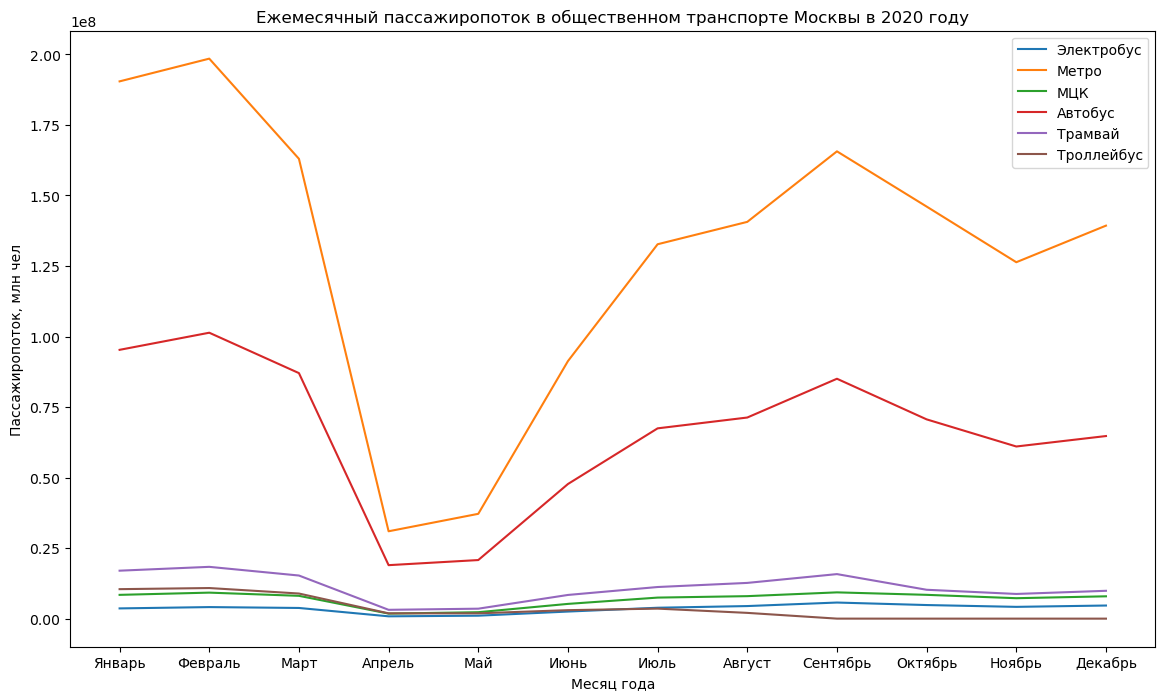

In [17]:
#Создание списка с месяцами для оси Х
x = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
plt.figure(figsize=(14,8))
plt.plot(x, passengerselectrobus, label='Электробус')
plt.plot(x, passengersmetro, label='Метро')
plt.plot(x, passengersMCC, label='МЦК')
plt.plot(x, passengersbus, label='Автобус')
plt.plot(x, passengerstram, label='Трамвай')
plt.plot(x, passengerstrolley, label='Троллейбус')
plt.xlabel('Месяц года')
plt.ylabel('Пассажиропоток, млн чел')
plt.title(f'Ежемесячный пассажиропоток в общественном транспорте Москвы в {year} году')
plt.legend()
plt.show()